In [1]:
import sys
sys.path.append('..')

In [2]:
from src.l1_tools import *
from src.Case_2_tools import *
import pandas as pd


In [ ]:
df = pd.read_csv("../data/Case_2/processed/cloudy_sky_mean_profiles.csv")

analog_parallel = df["RCS_04"].values
analog_perpendicular = df["RCS_02"].values

altitude = df["Altitude_m"].values

In [4]:
df = pd.read_csv("../data/Case_2/processed/molecular_profiles_reference.csv")

AMB_clear = df["AMB_clear"].values
AMB_clear_parallel = df["AMB_clear_parallel"].values
AMB_clear_perpendicular = df["AMB_clear_perpendicular"].values
beta_ray = df["beta_ray"].values
beta_ray_parallel = df["beta_ray_parallel"].values
beta_ray_perpendicular = df["beta_ray_perpendicular"].values


In [5]:

rcs_analog_par=gaussian_filter(analog_parallel , altitude , max_sigma=5  )
rcs_analog_per=gaussian_filter(analog_perpendicular , altitude , max_sigma=5  )

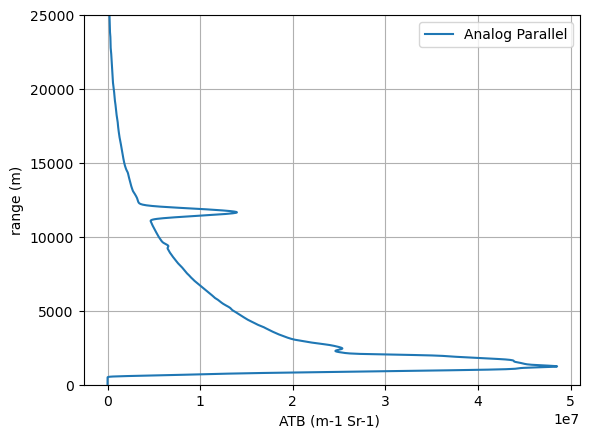

In [6]:
plt.plot( rcs_analog_par , altitude, label="Analog Parallel")
plt.ylim(000, 25000)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.grid(True)
plt.legend()


In [11]:

alt_mol_min = 6000
alt_mol_max = 7500


alt_cirrus_min = 11500
alt_cirrus_max = 12000

fitted_masx  = [[5500, 8000], [14000, 16000]]

Rcs_per_fitted = fit_clear_sky(altitude, rcs_analog_per, fitted_masx)
Rcs_par_fitted = fit_clear_sky(altitude, rcs_analog_par, fitted_masx)

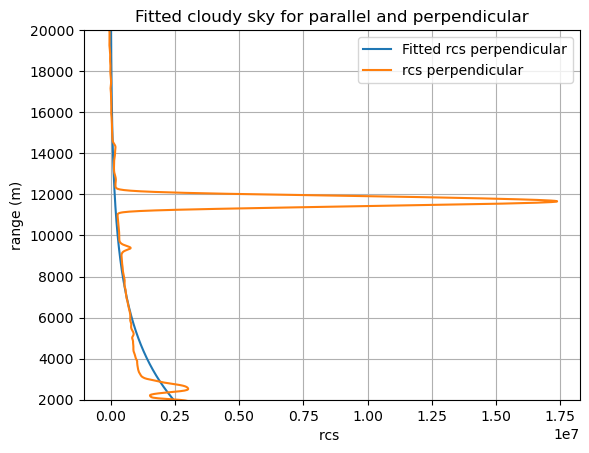

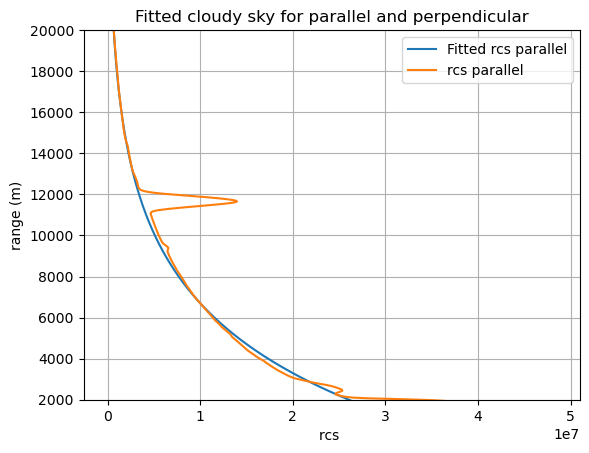

In [12]:


plt.figure()
plt.title("Fitted cloudy sky for parallel and perpendicular")
plt.plot(Rcs_per_fitted , altitude , label="Fitted rcs perpendicular")
plt.plot(rcs_analog_per , altitude , label="rcs perpendicular ")  
plt.ylim(2000 , 20000)
plt.grid(True)
plt.xlabel("rcs ")
plt.ylabel("range (m)")
plt.legend()



plt.figure()
plt.title("Fitted cloudy sky for parallel and perpendicular")
plt.plot(Rcs_par_fitted , altitude , label="Fitted rcs parallel")
plt.plot(rcs_analog_par , altitude , label="rcs parallel ")  
plt.ylim(2000 , 20000)
plt.grid(True)
plt.xlabel("rcs ")
plt.ylabel("range (m)")
plt.legend()

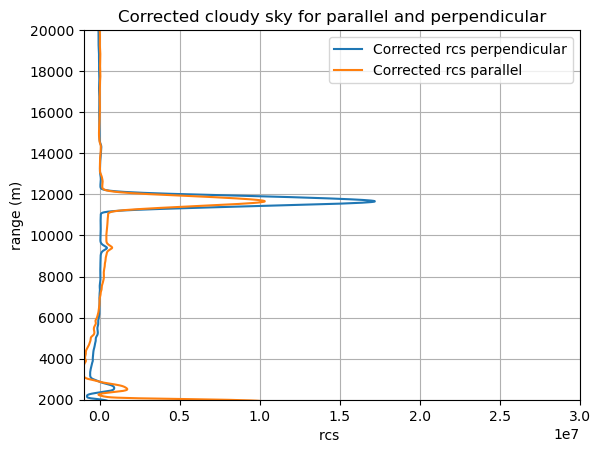

In [18]:
Rcs_per_Corrected = rcs_analog_per- Rcs_per_fitted
Rcs_par_Corrected = rcs_analog_par - Rcs_par_fitted

plt.figure()
plt.title("Corrected cloudy sky for parallel and perpendicular")
plt.plot(Rcs_per_Corrected , altitude , label="Corrected rcs perpendicular")
plt.plot(Rcs_par_Corrected , altitude , label="Corrected rcs parallel")
plt.ylim(2000 , 20000)
plt.xlim(-1e6 , 3e7)
plt.grid(True)
plt.xlabel("rcs ")
plt.ylabel("range (m)")
plt.legend()


In [32]:

Pic_parall_meas_cirrus , Pic_perp_meas_cirrus   , alt_cirrus = get_max_values(Rcs_par_Corrected , Rcs_per_Corrected, altitude, alt_cirrus_min, alt_cirrus_max)
indx_for_depol = np.argmin(np.abs(altitude - alt_cirrus))


d1, d2, d3, d4 = calibrate_step_2(AMB_clear_parallel,rcs_analog_par , rcs_analog_per , Pic_perp_meas_cirrus  ,Pic_parall_meas_cirrus , depol_mol =0.004  , depol_cirrus =0.3, alt =altitude , alt_min_mol = alt_mol_min , alt_max_mol = alt_mol_max )

gamma = d2 / d1

print("d1:", d1)
print("d2:", d2)
print("d4:", d4)
print("gamma (d2/d1):", gamma)



d1: 3.954781327095048e-14
d2: -1.8153084598951724e-15
d4: 2.1359053061776823e-13
gamma (d2/d1): -0.04590161401486621


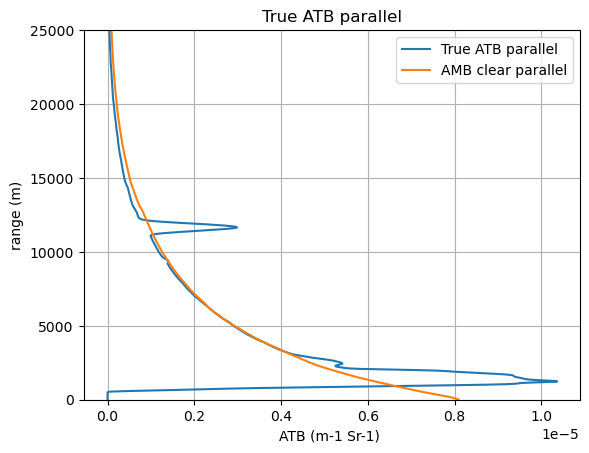

In [33]:
ATB_parallel_true = d4*rcs_analog_par

plt.figure()
plt.title("True ATB parallel")
plt.plot(ATB_parallel_true , altitude , label="True ATB parallel")
plt.plot(AMB_clear_parallel , altitude , label="AMB clear parallel")
plt.ylim(000, 25000)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.grid(True)
plt.legend()


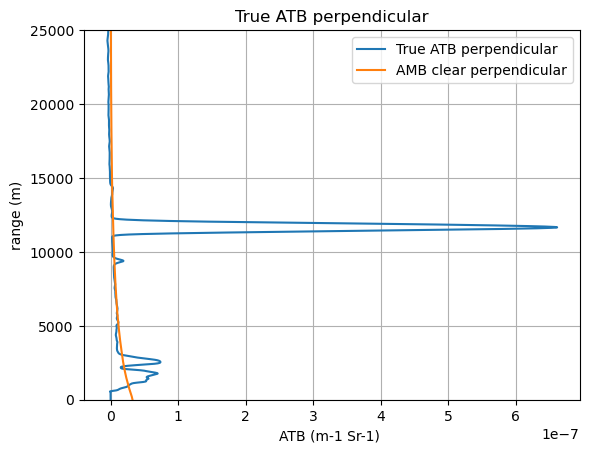

In [34]:
ATB_perp_true = d1*rcs_analog_per + d2*rcs_analog_par

plt.figure()
plt.title("True ATB perpendicular")
plt.plot(ATB_perp_true , altitude , label="True ATB perpendicular")
plt.plot(AMB_clear_perpendicular , altitude , label="AMB clear perpendicular")
plt.ylim(000, 25000)
plt.xlabel("ATB (m-1 Sr-1) ")
plt.ylabel("range (m)")
plt.grid(True)
plt.legend()


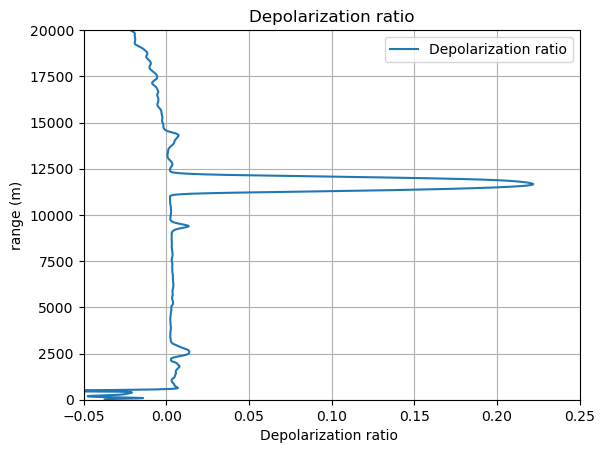

In [39]:
depol = (ATB_perp_true )/(ATB_parallel_true)

plt.figure()
plt.title("Depolarization ratio")
plt.plot(depol , altitude , label="Depolarization ratio")
plt.ylim(000, 20000)
plt.xlim(-0.05, 0.25)
plt.xlabel("Depolarization ratio ")
plt.ylabel("range (m)")
plt.grid(True)
plt.legend()    